# **Regularization Techniques in Convolutional Neural Networks**
Deep learning models often achieve high training accuracy but may perform poorly on unseen data due to overfitting. Regularization techniques are used to improve a model's ability to generalize by reducing its tendency to memorize the training dataset.

In this project, a Convolutional Neural Network (CNN) was trained on the CIFAR-10 image classification dataset using the Adam optimizer. The performance of the baseline model was compared with several regularization techniques, including Dropout, L2 Regularization, Batch Normalization, and Data Augmentation. A final model combining multiple regularization methods was also evaluated.

The objective of this notebook is to study the impact of these techniques on training and validation performance, analyze their effectiveness in reducing overfitting, and identify which approach provides the best balance between model complexity and generalization.

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.datasets import cifar10

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [ ]:
x_train = x_train/255
x_test = x_test/255

## Base Model
The baseline model serves as the reference architecture for all experiments in this notebook. It consists of two convolutional layers followed by max-pooling layers, a fully connected dense layer, and an output layer for classification. The model is trained on the CIFAR-10 dataset using the Adam optimizer without any regularization techniques such as Dropout, L2 Regularization, Batch Normalization, or Data Augmentation.

The purpose of the baseline model is to establish a performance benchmark against which the effectiveness of different regularization techniques can be evaluated. By first observing the behavior of an unregularized network, it becomes easier to identify issues such as overfitting and assess how each technique impacts model generalization.

In [ ]:
model_base = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [ ]:
model_base.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history_adam = model_base.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split = 0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 158ms/step - accuracy: 0.4317 - loss: 1.5845 - val_accuracy: 0.5215 - val_loss: 1.3661
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 160ms/step - accuracy: 0.5698 - loss: 1.2219 - val_accuracy: 0.5939 - val_loss: 1.1637
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 144ms/step - accuracy: 0.6247 - loss: 1.0733 - val_accuracy: 0.6145 - val_loss: 1.0861
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 152ms/step - accuracy: 0.6580 - loss: 0.9788 - val_accuracy: 0.6478 - val_loss: 1.0195
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.6855 - loss: 0.9090 - val_accuracy: 0.6663 - val_loss: 0.9652
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 155ms/step - accuracy: 0.7041 - loss: 0.8526 - val_accuracy: 0.6595 - val_loss: 0.9691
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.7239 - loss: 0.8010 - val_accuracy: 0.6733 - val_loss: 0.9470
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 142ms/step - accuracy: 0.7415 - loss: 0

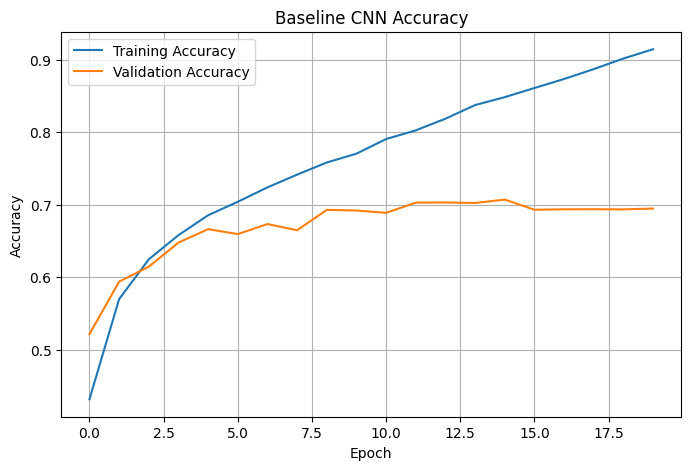

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_adam.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_adam.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Baseline CNN Accuracy')
plt.legend()
plt.grid(True)

plt.show()

The baseline CNN achieved strong training performance, with training accuracy steadily increasing from approximately 43% to over 91% by the end of training. However, validation accuracy plateaued around 70% after the first few epochs and showed little improvement despite continued gains in training accuracy.

The growing gap between training and validation accuracy indicates clear overfitting. While the model learned the training data extremely well, its ability to generalize to unseen images was limited. This behavior highlights the need for regularization techniques, which aim to reduce overfitting and improve performance on unseen data. The baseline model therefore provides a useful benchmark for evaluating whether techniques such as Dropout, L2 Regularization, Batch Normalization, and Data Augmentation can improve generalization performance.

## Dropout
Dropout is a regularization technique designed to reduce overfitting in neural networks. During training, a fraction of neurons is randomly deactivated, preventing the network from becoming overly dependent on specific features or pathways. This encourages the model to learn more robust and generalized representations of the data.

In this experiment, a Dropout layer with a rate of 0.5 was added after the dense layer of the baseline CNN. This means that 50% of the neurons in that layer were randomly ignored during each training step. The objective was to determine whether Dropout could improve the model's ability to generalize to unseen CIFAR-10 images.

In [ ]:
from tensorflow.keras.layers import Dropout

model_dropout = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_dropout.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history_dropout = model_dropout.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split = 0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 156ms/step - accuracy: 0.3544 - loss: 1.7625 - val_accuracy: 0.5066 - val_loss: 1.4242
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 151ms/step - accuracy: 0.4848 - loss: 1.4354 - val_accuracy: 0.5600 - val_loss: 1.2782
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.5358 - loss: 1.3061 - val_accuracy: 0.5975 - val_loss: 1.1714
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.5623 - loss: 1.2341 - val_accuracy: 0.6133 - val_loss: 1.1222
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 153ms/step - accuracy: 0.5898 - loss: 1.1599 - val_accuracy: 0.6371 - val_loss: 1.0589
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step - accuracy: 0.6105 - loss: 1.1037 - val_accuracy: 0.6244 - val_loss: 1.0800
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.6283 - loss: 1.0625 - val_accuracy: 0.6602 - val_loss: 0.9898
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 145ms/step - accuracy: 0.6411 - loss: 1

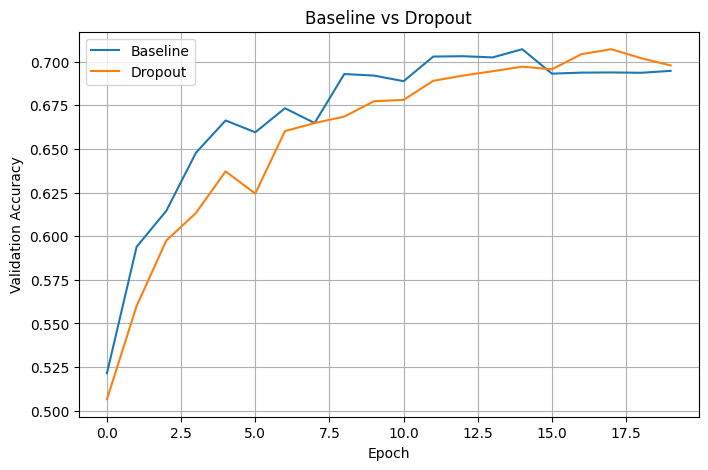

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_adam.history['val_accuracy'],
         label='Baseline')

plt.plot(history_dropout.history['val_accuracy'],
         label='Dropout')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Baseline vs Dropout')
plt.legend()
plt.grid(True)

plt.show()

The Dropout model initially learned more slowly than the baseline model, resulting in lower validation accuracy during the early epochs. However, as training progressed, the performance steadily improved and eventually matched and slightly exceeded the baseline model.

The graph shows that while the baseline model reached its peak validation accuracy earlier, the Dropout model continued improving throughout training and achieved a slightly higher peak validation accuracy of approximately 70.8%. This suggests that Dropout successfully reduced overfitting by preventing the network from relying too heavily on individual neurons.

Overall, Dropout provided a small improvement in generalization performance while producing a more stable learning curve. Although the gains were modest, the technique demonstrated its effectiveness in controlling overfitting and improving validation performance on unseen data.

## L2 Regularization
L2 Regularization, also known as weight decay, is a technique used to reduce overfitting by discouraging the model from learning excessively large weight values. It achieves this by adding a penalty term to the loss function that is proportional to the square of the model's weights.

The intuition behind L2 Regularization is that simpler models with smaller weights are often better at generalizing to unseen data. In this experiment, an L2 penalty was applied to the convolutional and dense layers of the baseline CNN to investigate its effect on model performance and generalization on the CIFAR-10 dataset.

In [ ]:
from tensorflow.keras import regularizers

model_l2 = Sequential([
    Conv2D(
        32,
        (3,3),
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(32,32,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    Dense(10, activation='softmax')
])

In [ ]:
model_l2.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history_l2 = model_l2.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split = 0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 155ms/step - accuracy: 0.3966 - loss: 1.7833 - val_accuracy: 0.4668 - val_loss: 1.5885
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 154ms/step - accuracy: 0.5192 - loss: 1.4572 - val_accuracy: 0.5475 - val_loss: 1.4006
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.5639 - loss: 1.3474 - val_accuracy: 0.5584 - val_loss: 1.3670
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 147ms/step - accuracy: 0.5967 - loss: 1.2767 - val_accuracy: 0.5846 - val_loss: 1.3200
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 145ms/step - accuracy: 0.6149 - loss: 1.2300 - val_accuracy: 0.5988 - val_loss: 1.2766
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 144ms/step - accuracy: 0.6291 - loss: 1.1925 - val_accuracy: 0.6231 - val_loss: 1.2388
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 150ms/step - accuracy: 0.6468 - loss: 1.1541 - val_accuracy: 0.6392 - val_loss: 1.1904
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 153ms/step - accuracy: 0.6647 - loss: 1

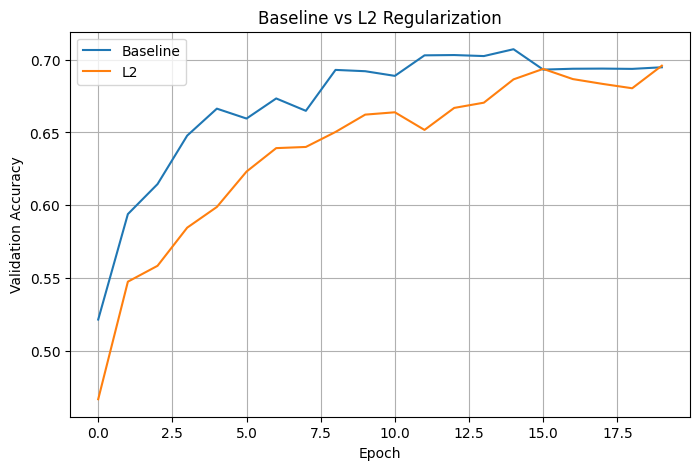

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_adam.history['val_accuracy'],
         label='Baseline')

plt.plot(history_l2.history['val_accuracy'],
         label='L2')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Baseline vs L2 Regularization')
plt.legend()
plt.grid(True)

plt.show()

The L2-regularized model exhibited a slower learning process compared to the baseline model, resulting in lower validation accuracy during the initial epochs. However, the model improved steadily throughout training and gradually closed the performance gap.

As shown in the graph, the baseline model achieved higher validation accuracy during most of the training process, but the L2 model continued improving while the baseline began to plateau. By the final epoch, both models reached nearly identical validation accuracies of approximately 69–70%.

These results indicate that L2 Regularization successfully constrained the model's complexity and reduced overfitting without significantly sacrificing performance. Although it did not produce a substantial increase in validation accuracy, it achieved comparable results while encouraging a simpler and more generalizable model.

## Batch Noramlization
Batch Normalization is a technique that normalizes the outputs of a layer during training by adjusting them to have a stable mean and variance. This helps reduce internal covariate shift, allowing the network to train more efficiently and making the optimization process more stable.

In this experiment, Batch Normalization layers were added after each convolutional layer in the baseline CNN. The goal was to examine whether normalizing intermediate activations could improve convergence speed, stabilize training, and enhance the model's generalization performance on the CIFAR-10 dataset.

In [ ]:
from tensorflow.keras.layers import BatchNormalization

model_bn = Sequential([
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    BatchNormalization(),

    Dense(10, activation='softmax')
])

In [ ]:
model_bn.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history_bn = model_bn.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split = 0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 204ms/step - accuracy: 0.5502 - loss: 1.2843 - val_accuracy: 0.2418 - val_loss: 2.5578
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 207ms/step - accuracy: 0.6839 - loss: 0.9100 - val_accuracy: 0.5578 - val_loss: 1.2479
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 214ms/step - accuracy: 0.7398 - loss: 0.7489 - val_accuracy: 0.6352 - val_loss: 1.1249
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 209ms/step - accuracy: 0.7851 - loss: 0.6191 - val_accuracy: 0.6606 - val_loss: 1.0487
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 211ms/step - accuracy: 0.8301 - loss: 0.4939 - val_accuracy: 0.6653 - val_loss: 1.0973
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 203ms/step - accuracy: 0.8702 - loss: 0.3865 - val_accuracy: 0.6689 - val_loss: 1.1005
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 205ms/step - accuracy: 0.9032 - loss: 0.2945 - val_accuracy: 0.6814 - val_loss: 1.0910
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 213ms/step - accuracy: 0.9323 - loss: 0

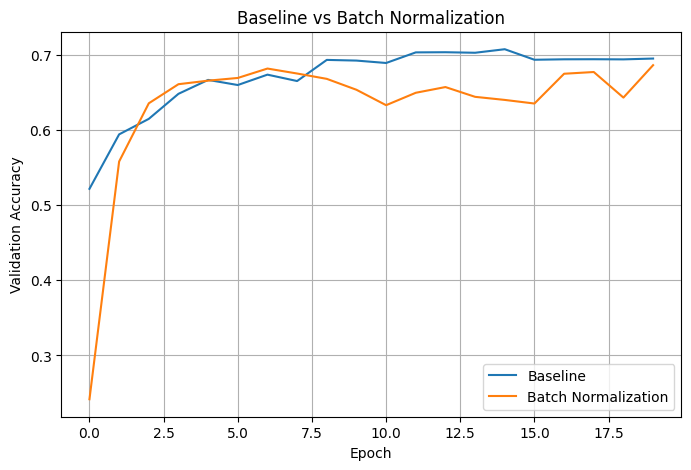

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_adam.history['val_accuracy'],
         label='Baseline')

plt.plot(history_bn.history['val_accuracy'],
         label='Batch Normalization')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Baseline vs Batch Normalization')
plt.legend()
plt.grid(True)

plt.show()

The Batch Normalization model learned very quickly during the initial epochs, rapidly reaching validation accuracies comparable to the baseline model. This demonstrates Batch Normalization's ability to stabilize training and accelerate convergence.

As shown in the graph, the model achieved its peak validation accuracy relatively early but experienced noticeable fluctuations throughout training. While the baseline model maintained a more consistent performance after convergence, the Batch Normalization model showed greater variability in validation accuracy across epochs.

Overall, Batch Normalization provided training stability and fast convergence but did not significantly improve final validation accuracy. The model achieved performance comparable to the baseline CNN, indicating that while Batch Normalization can make training more efficient, its impact on generalization was limited for this particular architecture and dataset.

## Data Augumentation
Data augmentation is a regularization technique that artificially increases the diversity of the training dataset by applying random transformations to the input images. Common transformations include horizontal flipping, rotation, zooming, and shifting. By exposing the model to modified versions of the same images, data augmentation helps reduce overfitting and improves the model's ability to generalize to unseen data.

In this experiment, data augmentation layers were applied before the CNN architecture. The objective was to evaluate whether increasing training data variability could improve validation performance compared to the baseline model.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

model_aug = Sequential([
    data_augmentation,

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [ ]:
model_aug.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history_aug = model_aug.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split = 0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 166ms/step - accuracy: 0.3853 - loss: 1.6935 - val_accuracy: 0.4461 - val_loss: 1.5920
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.4898 - loss: 1.4281 - val_accuracy: 0.5279 - val_loss: 1.3103
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 166ms/step - accuracy: 0.5268 - loss: 1.3225 - val_accuracy: 0.5457 - val_loss: 1.3003
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 171ms/step - accuracy: 0.5553 - loss: 1.2564 - val_accuracy: 0.5521 - val_loss: 1.2728
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 167ms/step - accuracy: 0.5717 - loss: 1.2080 - val_accuracy: 0.6062 - val_loss: 1.1304
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.5900 - loss: 1.1635 - val_accuracy: 0.6140 - val_loss: 1.1329
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.6025 - loss: 1.1312 - val_accuracy: 0.6161 - val_loss: 1.1052
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 171ms/step - accuracy: 0.6090 - loss: 1

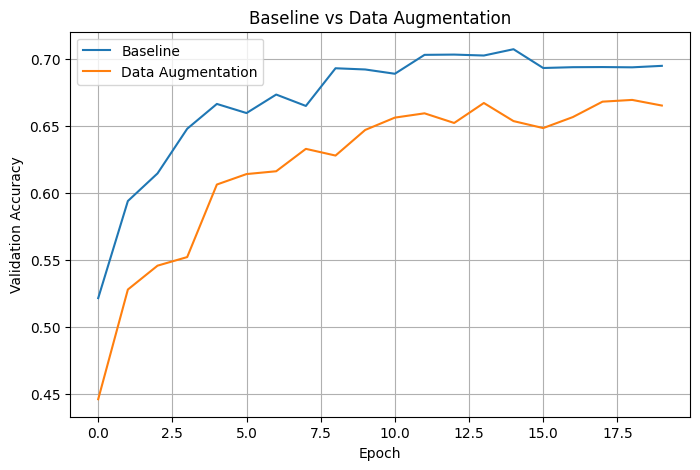

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history_adam.history['val_accuracy'],
         label='Baseline')

plt.plot(history_aug.history['val_accuracy'],
         label='Data Augmentation')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Baseline vs Data Augmentation')
plt.legend()
plt.grid(True)

plt.show()

The graph shows that the model trained with data augmentation consistently achieved lower validation accuracy than the baseline model throughout most of the training process. While the baseline model reached a peak validation accuracy of approximately 69.95%, the data augmentation model achieved a maximum validation accuracy of approximately 68.38%.

The slower improvement observed in the augmented model is expected because the training images become more challenging due to random transformations. Although data augmentation did not outperform the baseline model in terms of validation accuracy within the limited number of training epochs, it reduced the gap between training and validation performance, indicating less overfitting. With a larger network architecture or longer training duration, data augmentation may provide greater benefits and potentially surpass the baseline model's performance.

## Combined Model

In [30]:
model_final = Sequential([
    data_augmentation,

    Conv2D(
        32,
        (3,3),
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        input_shape=(32,32,3)
    ),

    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    Dropout(0.3),

    Dense(10, activation='softmax')
])

In [31]:
model_final.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history_final = model_final.fit(
    x_train,
    y_train,
    epochs=40,
    batch_size=128,
    validation_split = 0.2
)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 246ms/step - accuracy: 0.3965 - loss: 1.9851 - val_accuracy: 0.2608 - val_loss: 2.8768
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 238ms/step - accuracy: 0.4895 - loss: 1.6660 - val_accuracy: 0.5182 - val_loss: 1.6000
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 233ms/step - accuracy: 0.5235 - loss: 1.5337 - val_accuracy: 0.5745 - val_loss: 1.3915
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 233ms/step - accuracy: 0.5552 - loss: 1.4466 - val_accuracy: 0.5796 - val_loss: 1.4062
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 229ms/step - accuracy: 0.5738 - loss: 1.3870 - val_accuracy: 0.5174 - val_loss: 1.6475
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 238ms/step - accuracy: 0.5895 - loss: 1.3416 - val_accuracy: 0.5857 - val_loss: 1.3801
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 233ms/step - accuracy: 0.6013 - loss: 1.3112 - val_accuracy: 0.6131 - val_loss: 1.2948
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 228ms/step - accuracy: 0.6125 - loss: 1

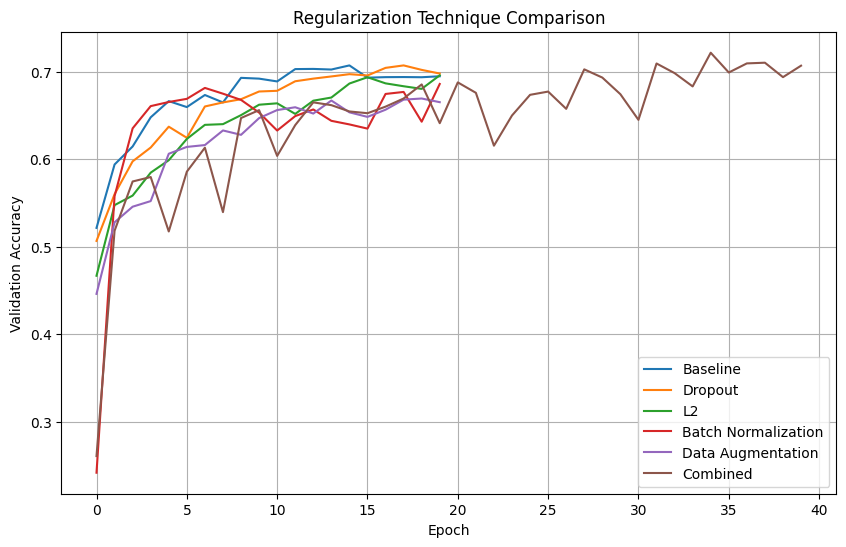

In [32]:
plt.figure(figsize=(10,6))

plt.plot(history_adam.history['val_accuracy'],
         label='Baseline')

plt.plot(history_dropout.history['val_accuracy'],
         label='Dropout')

plt.plot(history_l2.history['val_accuracy'],
         label='L2')

plt.plot(history_bn.history['val_accuracy'],
         label='Batch Normalization')

plt.plot(history_aug.history['val_accuracy'],
         label='Data Augmentation')

plt.plot(history_final.history['val_accuracy'],
         label='Combined')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Regularization Technique Comparison')
plt.legend()
plt.grid(True)

plt.show()

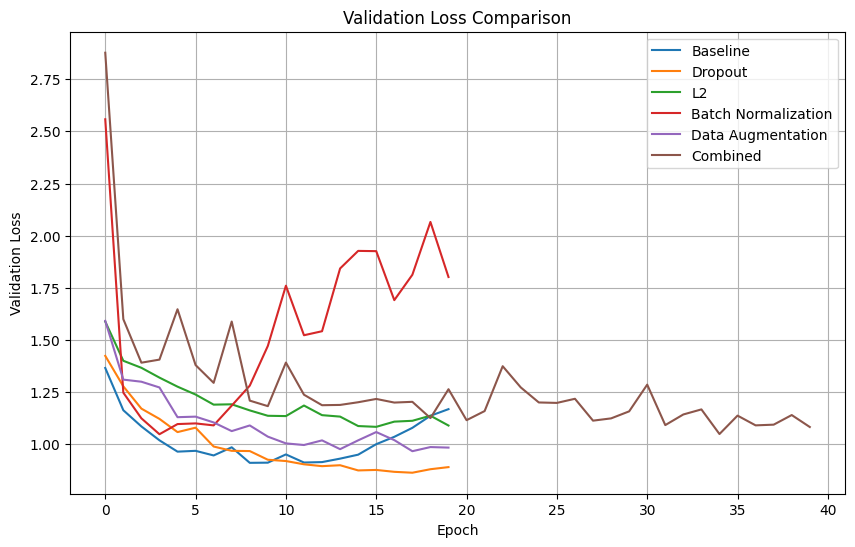

In [33]:
plt.figure(figsize=(10,6))

plt.plot(history_adam.history['val_loss'],
         label='Baseline')

plt.plot(history_dropout.history['val_loss'],
         label='Dropout')

plt.plot(history_l2.history['val_loss'],
         label='L2')

plt.plot(history_bn.history['val_loss'],
         label='Batch Normalization')

plt.plot(history_aug.history['val_loss'],
         label='Data Augmentation')

plt.plot(history_final.history['val_loss'],
         label='Combined')

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.grid(True)

plt.show()

In [34]:
results = {
    "Baseline": max(history_adam.history['val_accuracy']),
    "Dropout": max(history_dropout.history['val_accuracy']),
    "L2": max(history_l2.history['val_accuracy']),
    "BatchNorm": max(history_bn.history['val_accuracy']),
    "Data Augmentation": max(history_aug.history['val_accuracy']),
    "Combined": max(history_final.history['val_accuracy'])
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Baseline: 0.7071
Dropout: 0.7071
L2: 0.6958
BatchNorm: 0.6859
Data Augmentation: 0.6693
Combined: 0.7216


In [35]:
print("Baseline")
print("Train:", max(history_adam.history['accuracy']))
print("Val:", max(history_adam.history['val_accuracy']))

print("\nDropout")
print("Train:", max(history_dropout.history['accuracy']))
print("Val:", max(history_dropout.history['val_accuracy']))

print("\nL2")
print("Train:", max(history_l2.history['accuracy']))
print("Val:", max(history_l2.history['val_accuracy']))

print("\nBatchNorm")
print("Train:", max(history_bn.history['accuracy']))
print("Val:", max(history_bn.history['val_accuracy']))

print("\nData Augmentation")
print("Train:", max(history_aug.history['accuracy']))
print("Val:", max(history_aug.history['val_accuracy']))

print("\nCombined")
print("Train:", max(history_final.history['accuracy']))
print("Val:", max(history_final.history['val_accuracy']))

Baseline
Train: 0.9145249724388123
Val: 0.707099974155426

Dropout
Train: 0.7485250234603882
Val: 0.707099974155426

L2
Train: 0.763450026512146
Val: 0.6958000063896179

BatchNorm
Train: 0.9852749705314636
Val: 0.6858999729156494

Data Augmentation
Train: 0.6784499883651733
Val: 0.6693000197410583

Combined
Train: 0.7034500241279602
Val: 0.7215999960899353


## Conclusion
This notebook investigated the effect of several regularization techniques on the performance of a Convolutional Neural Network (CNN) trained on the CIFAR-10 dataset. The techniques evaluated were Dropout, L2 Regularization, Batch Normalization, Data Augmentation, and a Combined Model incorporating all techniques together. Performance was measured primarily using validation accuracy and validation loss.

The baseline CNN achieved a validation accuracy of 70.71%, serving as the reference point for comparison. Applying Dropout produced the same validation accuracy (70.71%) while significantly reducing training accuracy from 91.45% to 74.85%, indicating that it successfully reduced overfitting and improved generalization. L2 Regularization resulted in a validation accuracy of 69.58%, slightly below the baseline, but also reduced the gap between training and validation performance. Batch Normalization achieved 68.59% validation accuracy and exhibited unstable validation loss despite very high training accuracy (98.53%), suggesting that it did not provide a significant benefit for this relatively simple CNN architecture. Data Augmentation produced the lowest validation accuracy (66.93%) among the individual techniques. While augmentation generally improves robustness, the model architecture and training duration used in this experiment may not have been sufficient to fully exploit its benefits.

The Combined Model, which integrated Dropout, L2 Regularization, Batch Normalization, and Data Augmentation, achieved the highest validation accuracy of 72.16%, outperforming all individual models. Unlike the other models, which were trained for 20 epochs, the combined model was trained for 40 epochs to allow the effects of multiple regularization techniques to fully develop. Although its training accuracy (70.35%) was lower than the baseline, the validation accuracy was higher, indicating better generalization to unseen data. The validation loss comparison also showed that the combined approach maintained competitive performance throughout training, demonstrating that the combination of regularization techniques produced the most robust model in this study.

However, while the Combined Model produced the best overall accuracy, its validation curve was noticeably less stable. This suggests that more regularization techniques do not necessarily lead to smoother or more reliable training, and that selecting an appropriate combination of techniques may be more important than using all techniques simultaneously.